In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn import datasets
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             confusion_matrix)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline

In [2]:
iris = datasets.load_iris()

# 創建一個 DataFrame，包含特徵和目標變量

iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

<Figure size 1000x800 with 0 Axes>

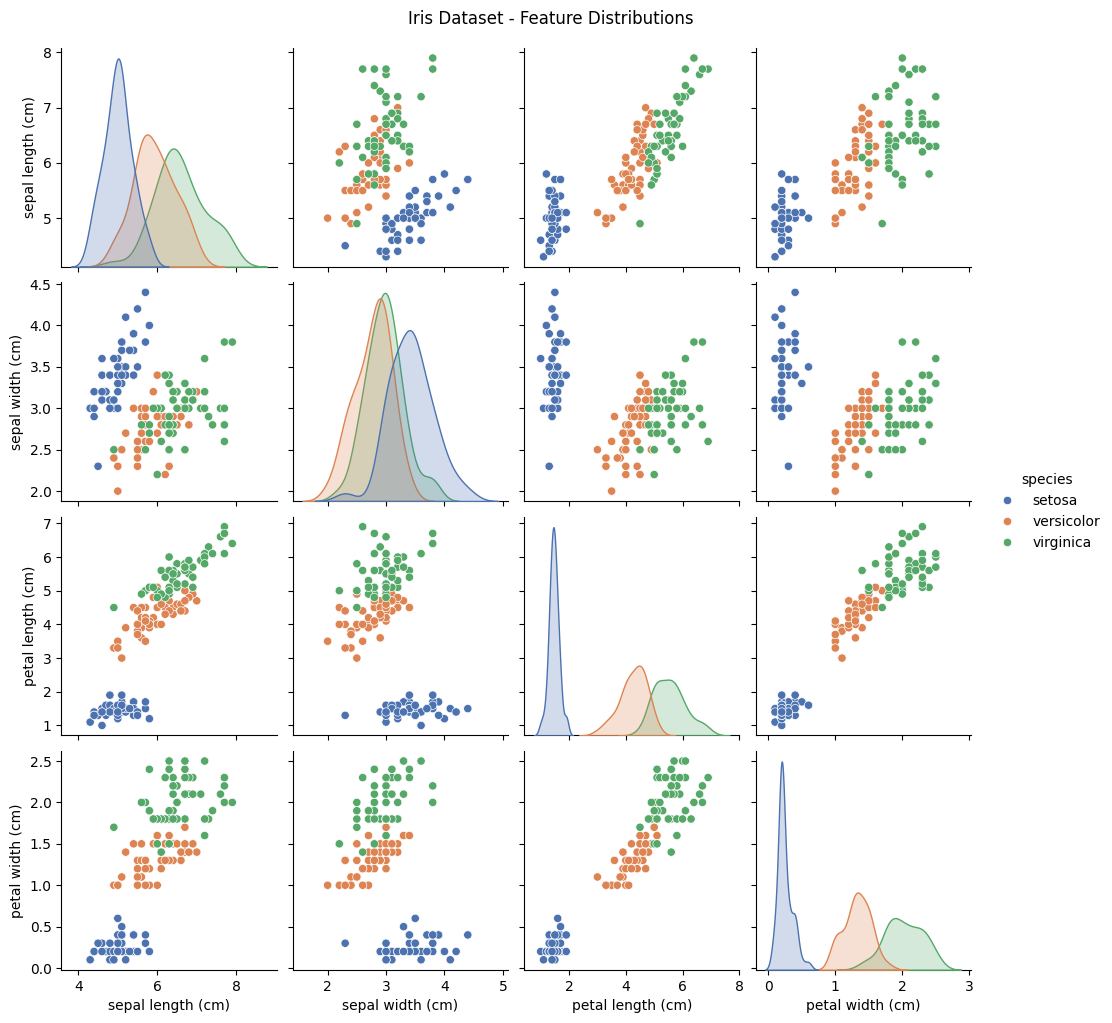

In [3]:
# 使用 Seaborn 創建 pairplot
plt.figure(figsize=(10, 8))
sns.pairplot(iris_df, hue='species', palette='deep')
plt.suptitle("Iris Dataset - Feature Distributions", y=1.02)
plt.show()

In [4]:
# X只取第2跟第3維
X = iris.data[:, [2, 3]]
# 0:setosa, 1:versicolor, 2:virginica
X = X[iris.target != 2] # 只取前兩類，排除virginica
# y只取前兩類
y = iris.target[iris.target != 2]
print('Class labels:', np.unique(y))

Class labels: [0 1]


In [5]:
# Splitting data into 70% training and 30% test data:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print('Labels count in y:', np.bincount(y))
print('Labels count in y_train:', np.bincount(y_train))
print('Labels count in y_test:', np.bincount(y_test))

Labels count in y: [50 50]
Labels count in y_train: [35 35]
Labels count in y_test: [15 15]


In [6]:
def plot_decision_regions_contour(X, y, classifier, test_idx=None, resolution=0.02):
    # 設置標記和顏色映射
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = plt.cm.RdYlBu

    # 繪製決策區域
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.activation(classifier.net_input(
        np.array([xx1.ravel(), xx2.ravel()]).T))
    Z = Z.reshape(xx1.shape)

    # 繪製等高線
    cs = plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.colorbar(cs)

    # 繪製訓練點
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.6,
                    c=colors[idx],
                    marker=markers[idx],
                    label=cl,
                    edgecolor='black')

    # 突出測試樣本
    if test_idx:
        X_test, y_test = X[test_idx, :], y[test_idx]
        plt.scatter(X_test[:, 0], X_test[:, 1],
                    c='', edgecolor='black', alpha=1.0,
                    linewidth=1, marker='o',
                    s=100, label='test set')

    # 設置圖表參數
    plt.xlabel('petal length [standardized]')
    plt.ylabel('petal width [standardized]')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.title('Logistic Regression Decision Regions')


def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],  y=X[y == cl, 1],
                    alpha=0.8,
                    color=colors[idx],
                    marker=markers[idx],
                    label=cl, edgecolor='black')

    # highlight test examples
    if test_idx:
        # plot all examples
        X_test, y_test = X[test_idx, :], y[test_idx]
        plt.scatter(X_test[:, 0], X_test[:, 1],
                    c='none', edgecolor='black',
                    alpha=1.0, linewidth=1, marker='o', s=100, label='test set')

In [7]:
# Standardizing the features:
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

In [8]:
class LogisticRegressionGD:
    """Logistic Regression Classifier using gradient descent.

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    random_state : int
      Random number generator seed for random weight
      initialization.


    Attributes
    -----------
    w_ : 1d-array
      Weights after fitting.
    cost_ : list
      Logistic cost function value in each epoch.

    """

    def __init__(self, eta=0.05, n_iter=100, random_state=42):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """ Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
          Training vectors, where n_examples is the number of examples and
          n_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.

        Returns
        -------
        self : object

        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.cost_ = []

        for i in range(self.n_iter):
            net_input = self.net_input(X)
            output = self.activation(net_input)
            errors = (output - y)
            self.w_[1:] -= self.eta * X.T.dot(errors)
            self.w_[0] -= self.eta * errors.sum()

            # note that we compute the logistic `cost` now
            # instead of the sum of squared errors cost
            cost = -y.dot(np.log(output)) - ((1 - y).dot(np.log(1 - output)))
            self.cost_.append(cost)
        return self

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activation(self, z):
        """Compute logistic sigmoid activation"""
        return 1. / (1. + np.exp(-np.clip(z, -100, 100)))

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.net_input(X) >= 0.0, 1, 0)
        # equivalent to:
        # return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

In [9]:
lrgd = LogisticRegressionGD(eta=0.05, n_iter=150)
lrgd.fit(X_train_std, y_train)

/tmp/ipykernel_241791/1900413703.py:65: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],  y=X[y == cl, 1],
/tmp/ipykernel_241791/1900413703.py:22: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


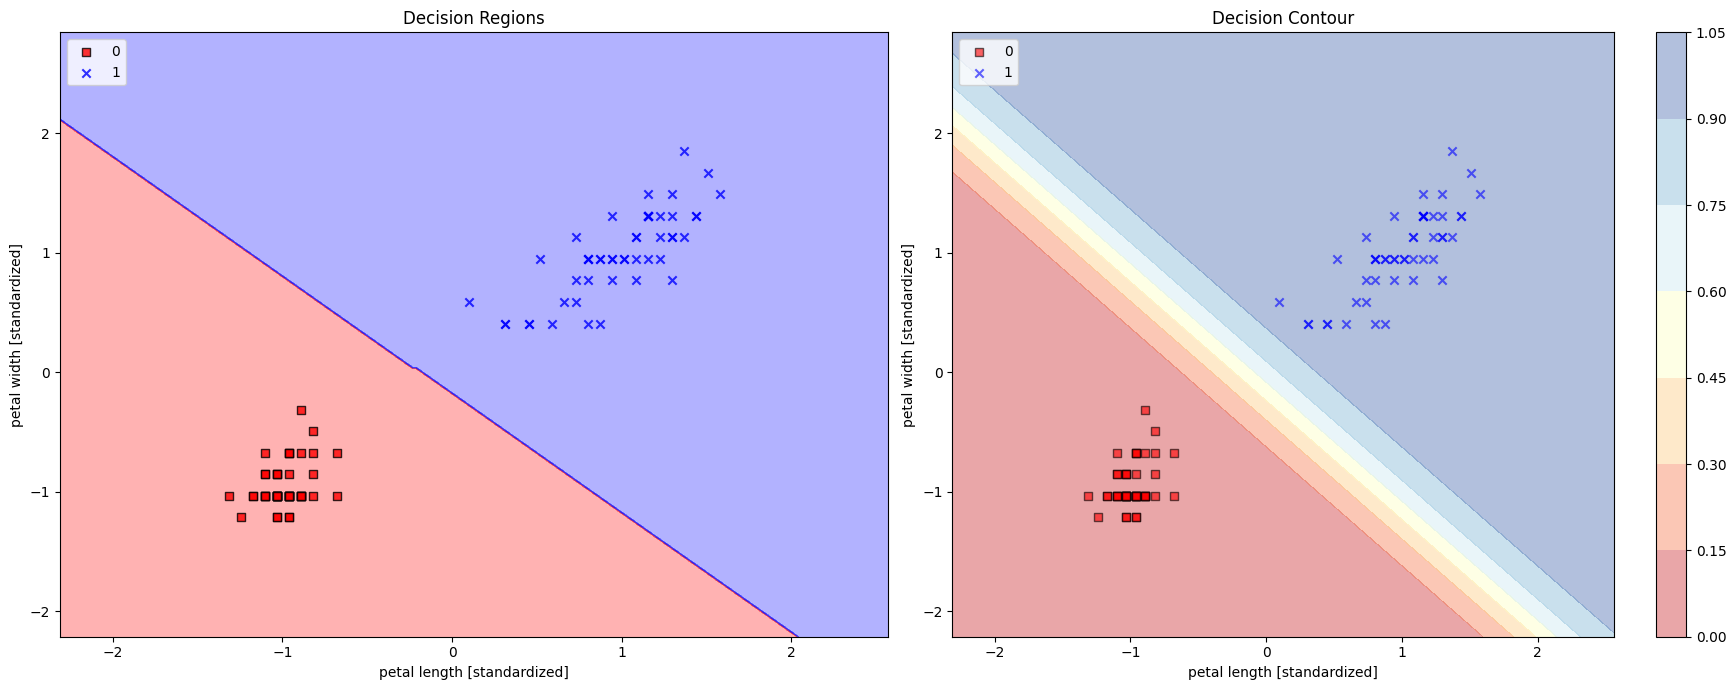

In [10]:
# 繪製決策邊界
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 左圖：決策邊界
plt.sca(axes[0])
plot_decision_regions(X_combined_std, y_combined, classifier=lrgd)
plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.title('Decision Regions')

# 右圖：等高線
plt.sca(axes[1])
plot_decision_regions_contour(X_combined_std, y_combined, classifier=lrgd)
plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.title('Decision Contour')

plt.tight_layout()
plt.show()

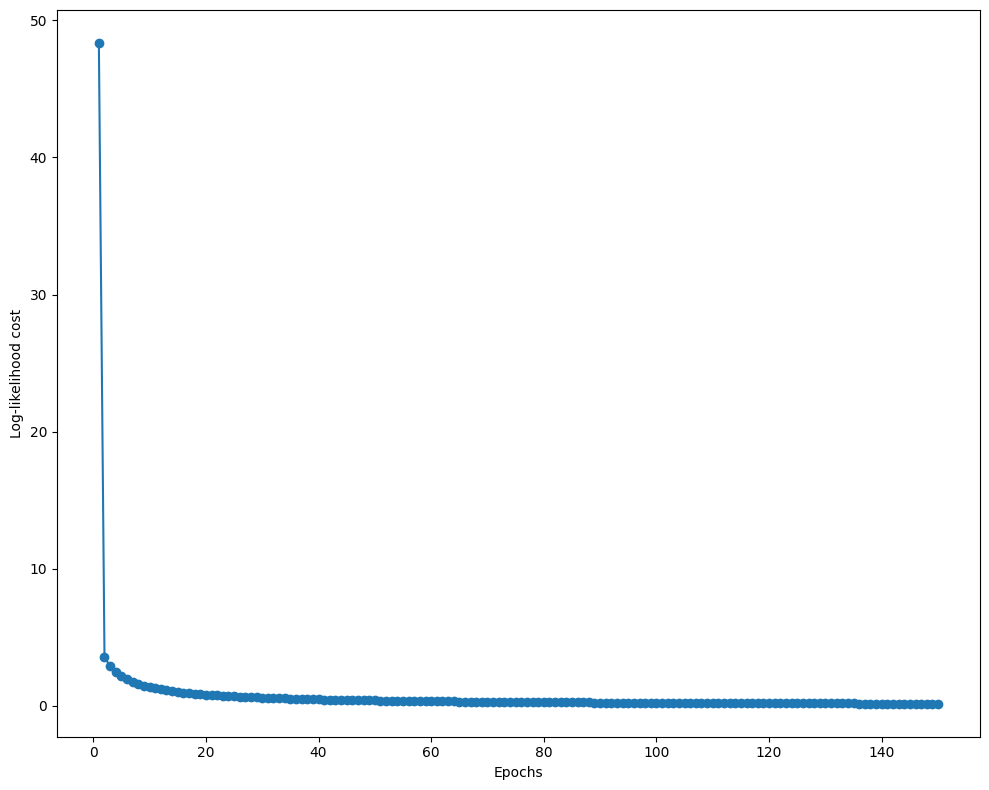

In [11]:
# 繪製成本函數
plt.figure(figsize=(10, 8))
plt.plot(range(1, len(lrgd.cost_) + 1), lrgd.cost_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Log-likelihood cost')
plt.tight_layout()
plt.show()

Misclassified examples: 0
自定義計算準確率: 1.000
sklearn 計算準確率: 1.000
兩種方法計算結果是否相同: True
Confusion Matrix:
[[15  0]
 [ 0 15]]


<Figure size 800x600 with 0 Axes>

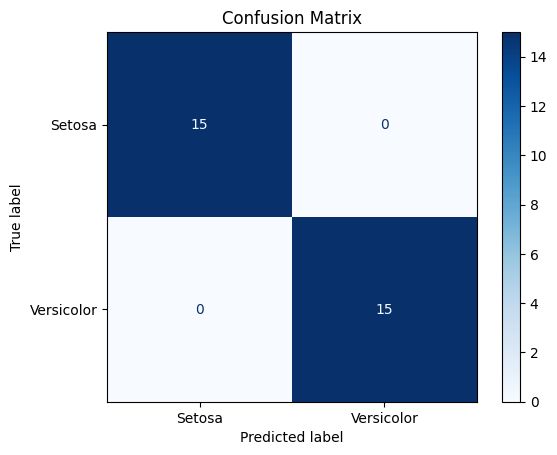

Precision: 1.000
Recall: 1.000
F1-score: 1.000


In [12]:
# 計算並輸出準確率
y_pred = lrgd.predict(X_test_std)
print('Misclassified examples: %d' % (y_test != y_pred).sum())
print('自定義計算準確率: %.3f' % ((y_test == y_pred).sum() / len(y_test)))

# 使用 sklearn 的 accuracy_score 函數計算準確率
sklearn_accuracy = accuracy_score(y_test, y_pred)
print('sklearn 計算準確率: %.3f' % sklearn_accuracy)
# 比較兩種方法的結果
print('兩種方法計算結果是否相同:', np.isclose(
    ((y_test == y_pred).sum() / len(y_test)), sklearn_accuracy))

# 計算並顯示混淆矩陣
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# 可視化混淆矩陣
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[
                              'Setosa', 'Versicolor'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1_score:.3f}")

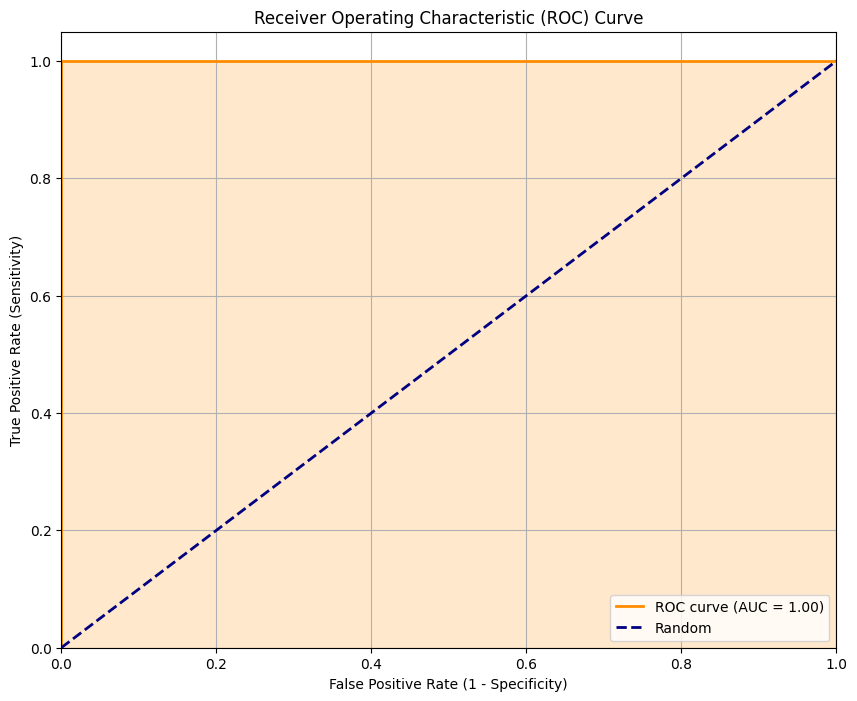

AUC Score: 1.000


In [13]:
# 計算並繪製 ROC AUC
from sklearn.metrics import roc_curve, auc

# 獲取預測的概率值而不是類別標籤
y_prob = lrgd.activation(lrgd.net_input(X_test_std))
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# 繪製 ROC 曲線
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2,
         linestyle='--', label='Random')
plt.fill_between(fpr, tpr, alpha=0.2, color='darkorange')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# 輸出 AUC 值
print(f'AUC Score: {roc_auc:.3f}')